In [1]:
import pandas as pd
df1 = pd.read_csv('results/primary_results.csv')
df2 = pd.read_csv('results/secondary_metrics.csv')
data = pd.merge(df1, df2, on=['dataset', 'model', 'precision', 'n_samples'])
data = data.rename(columns={
    'accuracy_%': 'accuracy',
    'pass@k_%': 'pass@k',
    'confidence_%': 'confidence',
    'reliability.diversity': 'diversity',
    'performance.tokens_per_sec': 'tps',
    'performance.total_time': 'total_time'
})

# Scale percentages back to fractions to match old summary_stats format
for col in ['accuracy', 'pass@k', 'confidence']:
    data[col] = data[col] / 100.0
data.head()

,dataset,model,precision,n_samples,accuracy,pass@k,acc_delta_vs_16bit_%,pass@k_delta_vs_16bit_%,confidence,n_questions,reliability.failure_rate,diversity,reliability.cutoff_rate,tps,performance.avg_latency_sec,total_time,performance.total_time_sec
0,cqa,Qwen/Qwen3.5-0.8B,4bit,8,0.5667,0.8665,-2.13,1.80,0.6785,1221,0.0013,2.6478,0.0004,218.63,4.63,1h 34m 8s,5647.63
1,cqa,Qwen/Qwen3.5-0.8B,8bit,8,0.5774,0.8649,-1.06,1.64,0.7130,1221,0.0002,2.4357,0.0023,275.60,7.66,2h 35m 51s,9350.89
2,cqa,Qwen/Qwen3.5-0.8B,16bit,8,0.5880,0.8485,0.00,0.00,0.7414,1221,0.0001,2.2875,0.0008,227.53,4.87,1h 39m 5s,5945.27
3,cqa,Qwen/Qwen3.5-0.8B,4bit,16,0.5725,0.9124,-2.54,1.15,0.6638,1221,0.0008,3.1925,0.0004,1884.99,1.39,28m 22s,1702.48
4,cqa,Qwen/Qwen3.5-0.8B,8bit,16,0.6003,0.9304,0.25,2.95,0.6916,1221,0.0002,2.9590,0.0028,219.36,14.72,4h 59m 33s,17973.43


In [2]:
# columns i want to display model, precision, dataset, accuracy, confidence, pass@k, diversity tps and total time n_questions
columns_to_display = ['model', 'precision', 'dataset', 'accuracy', 'confidence', 'pass@k', 'diversity', 'tps', 'total_time', 'n_questions']
df_filtered = data[columns_to_display].copy()
numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)
df_sorted = df_filtered.sort_values(by=['dataset', 'accuracy'])
df_filtered

,model,precision,dataset,accuracy,confidence,pass@k,diversity,tps,total_time,n_questions
0,Qwen/Qwen3.5-0.8B,4bit,cqa,0.567,0.678,0.866,2.648,218.63,1h 34m 8s,1221
1,Qwen/Qwen3.5-0.8B,8bit,cqa,0.577,0.713,0.865,2.436,275.60,2h 35m 51s,1221
2,Qwen/Qwen3.5-0.8B,16bit,cqa,0.588,0.741,0.848,2.288,227.53,1h 39m 5s,1221
3,Qwen/Qwen3.5-0.8B,4bit,cqa,0.572,0.664,0.912,3.192,1884.99,28m 22s,1221
4,Qwen/Qwen3.5-0.8B,8bit,cqa,0.600,0.692,0.930,2.959,219.36,4h 59m 33s,1221
5,Qwen/Qwen3.5-0.8B,16bit,cqa,0.598,0.719,0.901,2.734,236.24,2h 39m 36s,1221
6,meta-llama/Llama-3.2-1B-Instruct,4bit,cqa,0.604,0.762,0.834,2.156,185.09,1h 32m 13s,1221
7,meta-llama/Llama-3.2-1B-Instruct,8bit,cqa,0.591,0.761,0.853,2.158,450.04,31m 54s,1221
8,meta-llama/Llama-3.2-3B-Instruct,8bit,cqa,0.720,0.851,0.883,1.683,233.91,1h 21m 51s,1221
9,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.551,0.510,0.738,4.502,262.23,5h 43m 31s,1319


In [3]:
import pandas as pd

# Read the data
df1 = pd.read_csv('results/primary_results.csv')
df2 = pd.read_csv('results/secondary_metrics.csv')
data = pd.merge(df1, df2, on=['dataset', 'model', 'precision', 'n_samples'])
data = data.rename(columns={
    'accuracy_%': 'accuracy',
    'pass@k_%': 'pass@k',
    'confidence_%': 'confidence',
    'reliability.diversity': 'diversity',
    'performance.tokens_per_sec': 'tps',
    'performance.total_time': 'total_time'
})

# Scale percentages back to fractions to match old summary_stats format
for col in ['accuracy', 'pass@k', 'confidence']:
    data[col] = data[col] / 100.0

# Define the columns you want to display
columns_to_display = [
    'model', 
    'precision', 
    'dataset', 
    'accuracy', 
    'confidence', 
    'pass@k', 
    'diversity', 
    'tps', 
    'total_time', 
    'n_questions'
]

# Filter the dataframe to keep only the desired columns
df_filtered = data[columns_to_display].copy()

# Identify numeric columns to round
numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns

# Round the numeric columns to 3 decimal places
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)

# Sort by 'dataset', then by 'accuracy' (default is ascending order)
df_sorted = df_filtered.sort_values(by=['dataset', 'accuracy'],ascending=False)

# Display the result
df_sorted

# If you want to save this sorted view to a new CSV:
# df_sorted.to_csv('results/sorted_summary_stats.csv', index=False)

,model,precision,dataset,accuracy,confidence,pass@k,diversity,tps,total_time,n_questions
17,meta-llama/Llama-3.2-3B-Instruct,8bit,gsm8k,0.807,0.776,0.927,2.428,212.98,4h 35m 50s,1319
18,meta-llama/Llama-3.2-3B-Instruct,16bit,gsm8k,0.804,0.790,0.916,2.333,74.14,7h 56m 28s,808
14,Qwen/Qwen3.5-0.8B,16bit,gsm8k,0.665,0.563,0.880,6.196,3576.14,52m 4s,1319
13,Qwen/Qwen3.5-0.8B,8bit,gsm8k,0.663,0.549,0.873,6.413,860.56,3h 39m 34s,1319
11,Qwen/Qwen3.5-0.8B,16bit,gsm8k,0.650,0.583,0.812,3.942,252.35,5h 56m 55s,1319
10,Qwen/Qwen3.5-0.8B,8bit,gsm8k,0.637,0.564,0.830,4.090,273.51,5h 30m 8s,1319
12,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.578,0.487,0.828,7.257,980.37,4h 32m 25s,1319
9,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.551,0.510,0.738,4.502,262.23,5h 43m 31s,1319
16,meta-llama/Llama-3.2-1B-Instruct,8bit,gsm8k,0.456,0.495,0.679,4.582,433.44,1h 48m 50s,1319
15,meta-llama/Llama-3.2-1B-Instruct,4bit,gsm8k,0.453,0.471,0.696,4.729,195.51,4h 18m 39s,1319


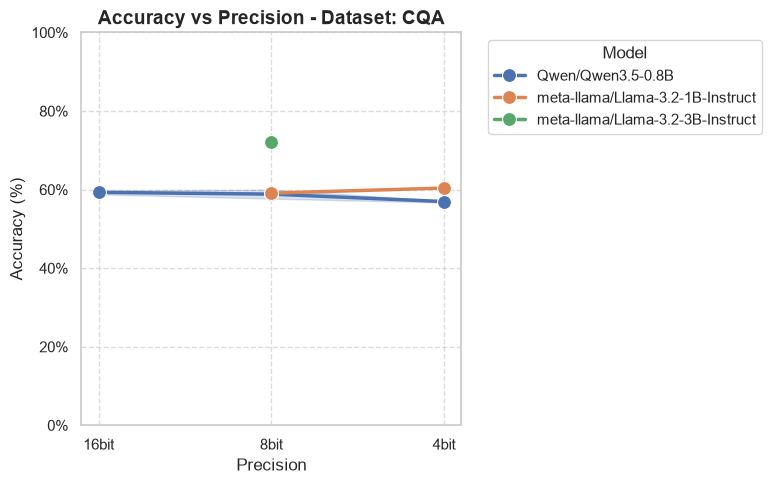

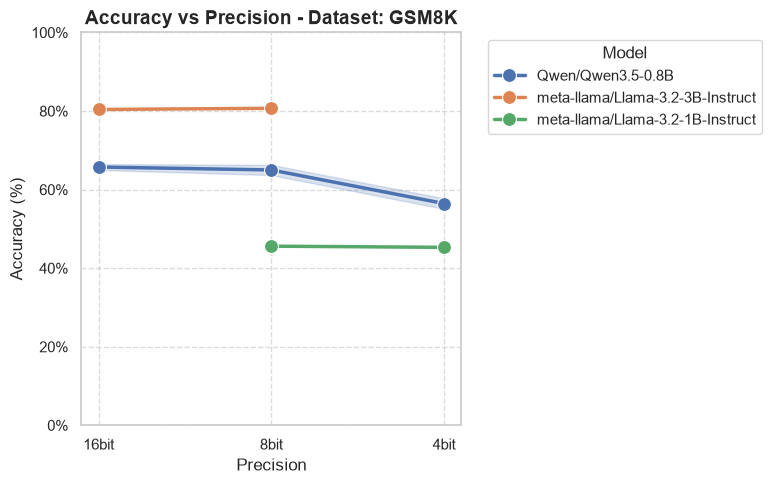

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Read and prepare the data
df1 = pd.read_csv('results/primary_results.csv')
df2 = pd.read_csv('results/secondary_metrics.csv')
data = pd.merge(df1, df2, on=['dataset', 'model', 'precision', 'n_samples'])
data = data.rename(columns={
    'accuracy_%': 'accuracy',
    'pass@k_%': 'pass@k',
    'confidence_%': 'confidence',
    'reliability.diversity': 'diversity',
    'performance.tokens_per_sec': 'tps',
    'performance.total_time': 'total_time'
})

# Scale percentages back to fractions to match old summary_stats format
for col in ['accuracy', 'pass@k', 'confidence']:
    data[col] = data[col] / 100.0

columns_to_display = [
    'model', 'precision', 'dataset', 'accuracy', 'confidence', 
    'pass@k', 'diversity', 'tps', 'total_time', 'n_questions'
]
df_filtered = data[columns_to_display].copy()

numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)

# 2. Get a list of unique datasets
datasets = df_filtered['dataset'].unique()

# Set a nice visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each dataset and create an individual line plot
for dataset_name in datasets:
    # Filter data for the current dataset
    df_subset = df_filtered[df_filtered['dataset'] == dataset_name].copy()
    
    # Sort precision logically (16bit -> 8bit -> 4bit) for the line flow
    precision_order = ['16bit', '8bit', '4bit']
    df_subset['precision'] = pd.Categorical(df_subset['precision'], categories=precision_order, ordered=True)
    df_subset = df_subset.sort_values('precision')
    
    # Create a new figure for each dataset
    plt.figure(figsize=(8, 5))
    
    # Create the line plot
    sns.lineplot(
        data=df_subset, 
        x='precision', 
        y='accuracy', 
        hue='model', 
        marker='o', 
        linewidth=2.5,
        markersize=10
    )
    
    # --- Y-AXIS CONFIGURATION ---
    # Force the Y-axis to go from 0 to 1.0 (0% to 100%)
    plt.ylim(0, 1.0)
    
    # Format the Y-axis to display as percentages (0%, 20%, 40%...)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    # ----------------------------
    
    # Add titles and labels
    plt.title(f'Accuracy vs Precision - Dataset: {dataset_name.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Precision', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    
    # Add a subtle grid for readability
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Place the legend outside the plot
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()


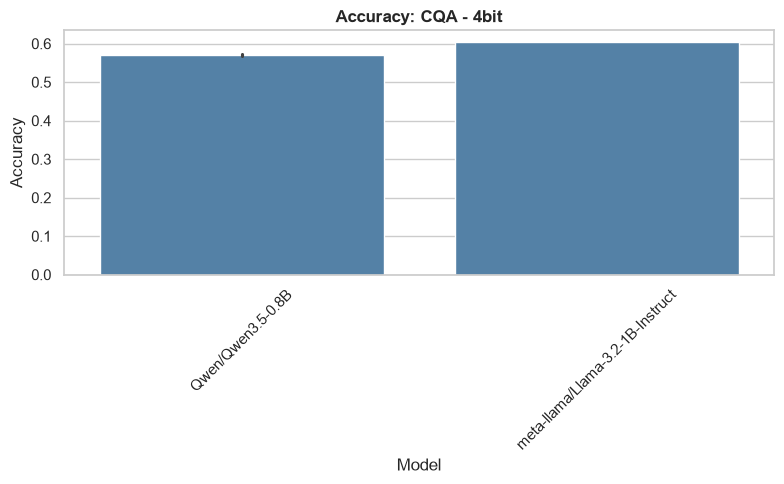

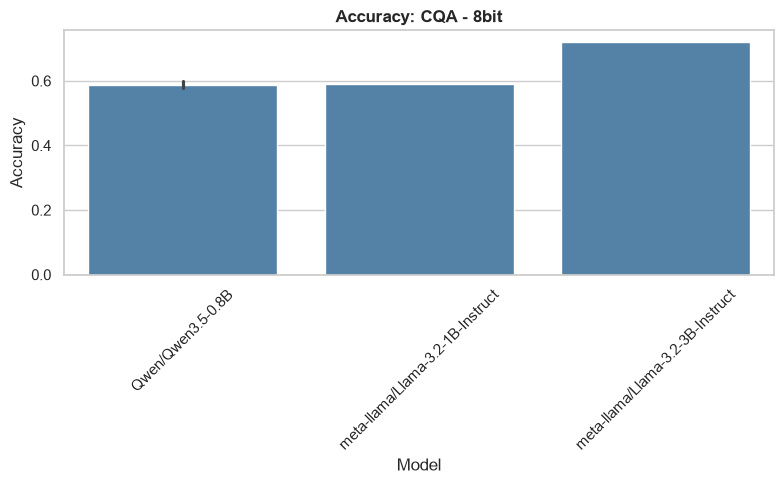

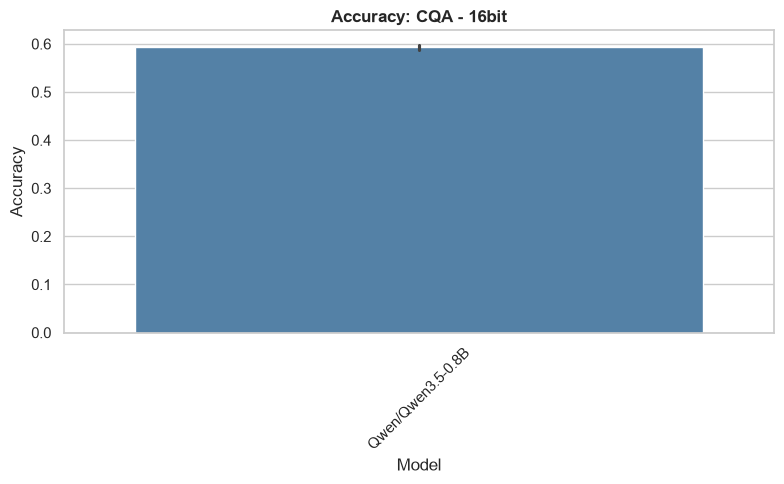

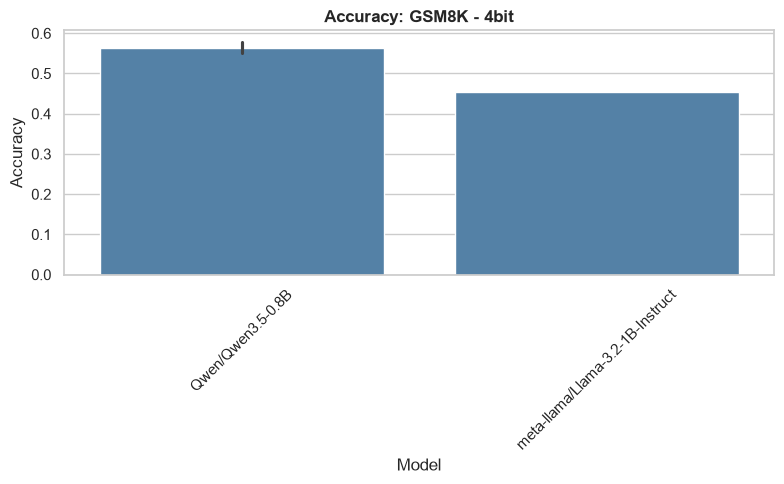

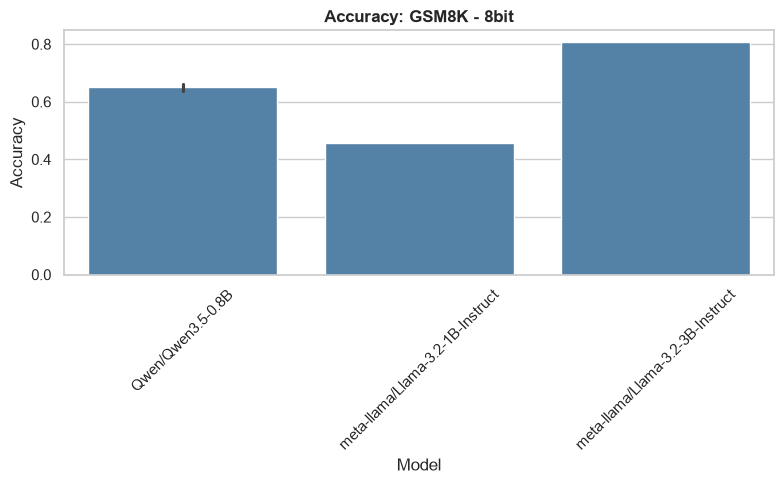

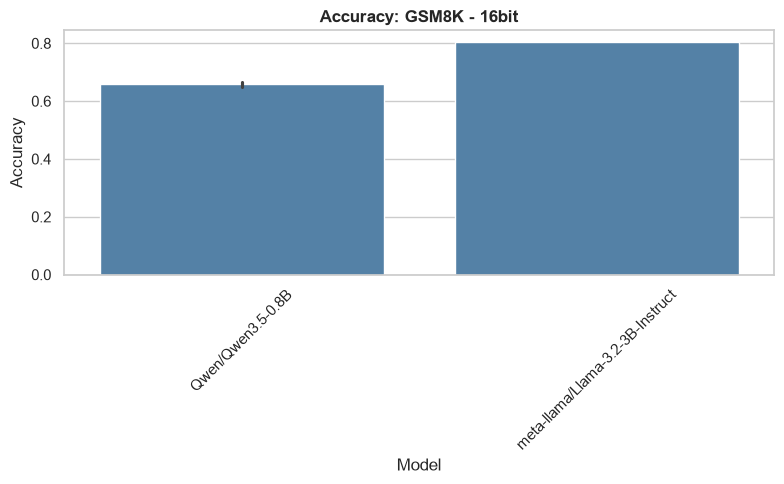

In [5]:
for dataset_name in datasets:
    df_dataset = df_filtered[df_filtered['dataset'] == dataset_name]
    precisions = df_dataset['precision'].unique()
    
    for precision in precisions:
        df_subset = df_dataset[df_dataset['precision'] == precision]
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=df_subset, x='model', y='accuracy', color='steelblue')
        
        plt.title(f'Accuracy: {dataset_name.upper()} - {precision}', fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45) # Rotate model names if they are long
        plt.tight_layout()
        plt.show()